# 🐍 Python Data Analyst Project: Movies

---
**Author**: DataAngel10  
 
**Date:** 13-04-2025

----

📊 In this project I explored the "Movies" dataset that includes thousands of films released between 1980 y 2020. The mentioned dataset was shared by Daniel Grijalva through Kaggle platform. The main objective was to analyze the relationship between the movie's budget and the gross revenue, but also to show skills in Python programming such as data cleaning, manipulation, visualization and statistical testing.

## Variables I used in this project:
- Budget: Numerical (in US Dollars).
- Gross: Numerical (in US Dollars).


## Technologies I Used:
- Python (pandas, numpy, seaborn, matplotlib).
- Jupyter Notebook.

# ✅ Import libreries and file

In [26]:
# data manipulation and analysis
import pandas as pd

# numerical calculations
import numpy as np

# statistical data visualization 
import seaborn as sns

# visualization
import matplotlib.pyplot as plt

# plot settings
import matplotlib

# to use ggplot style
plt.style.use('ggplot')
from matplotlib.pyplot import figure

# for display code in the notebook
%matplotlib inline

# figure size settings
matplotlib.rcParams['figure.figsize'] = (12, 8)

In [27]:
# Import dataset

df = pd.read_csv('/kaggle/input/movies/movies.csv')

# ✅ Understanding the data

In [28]:
# Exploring data
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [30]:
# Quick overview of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [31]:
# Checking missing data (loop through the data)
for col in df.columns:
    
     # Calculate the % of missing values in this column
    pct_missing = np.mean(df[col].isnull())

     # Print the column name and percentage of missing data
    print('{} - {}%'.format(col, round(pct_missing*100)))

name - 0%
rating - 1%
genre - 0%
year - 0%
released - 0%
score - 0%
votes - 0%
director - 0%
writer - 0%
star - 0%
country - 0%
budget - 28%
gross - 2%
company - 0%
runtime - 0%


In [32]:
# Explote data type
df.dtypes

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object

# ✅ Data cleaning 

In [33]:
# Dropped rows missing 'rating', 'budget', or 'gross' to keep the data clean 
df = df.dropna(subset=['rating', 'budget', 'gross'])

In [34]:
# Checking data to verify the cleaning 
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

name - 0%
rating - 0%
genre - 0%
year - 0%
released - 0%
score - 0%
votes - 0%
director - 0%
writer - 0%
star - 0%
country - 0%
budget - 0%
gross - 0%
company - 0%
runtime - 0%


In [35]:
# Change data type of columns
df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')
df['year'] = pd.to_datetime(df['year'], format='%Y')





In [36]:
# Verifying the tyoe changes
df.dtypes

name                object
rating              object
genre               object
year        datetime64[ns]
released            object
score              float64
votes              float64
director            object
writer              object
star                object
country             object
budget               int64
gross                int64
company             object
runtime            float64
dtype: object

In [37]:
# Organize by de gross revenue
df = df.sort_values(by=['gross'], inplace=False, ascending=False)

In [38]:
# Check for duplicate rows 
duplicates = df.duplicated()
print(duplicates.sum()) 

0


# ✅ Exploratory Data Analysis

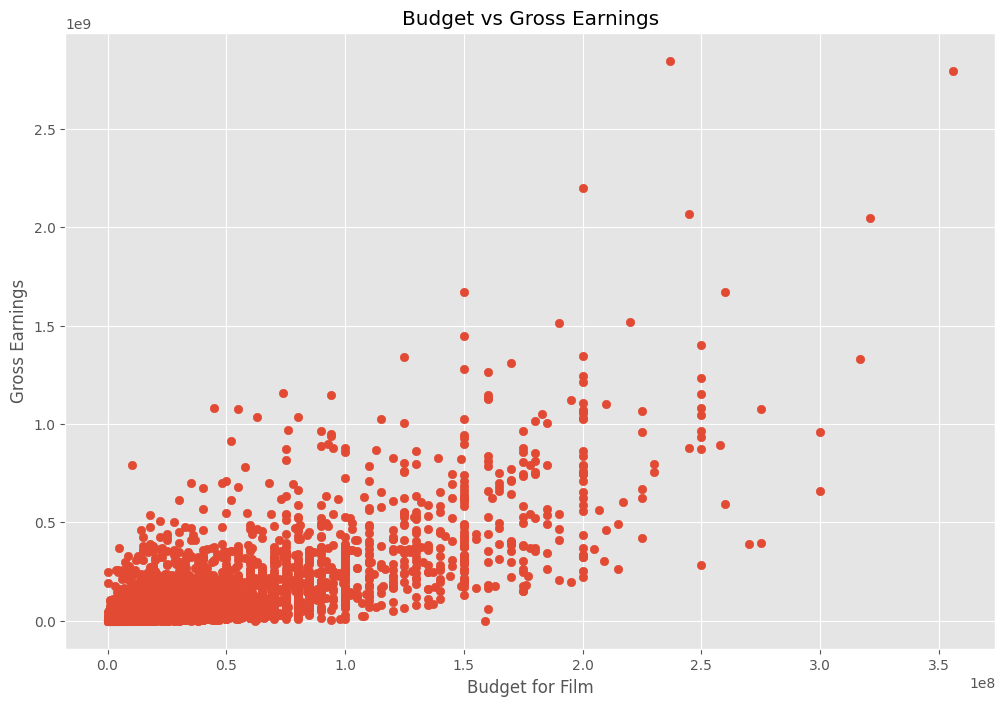

In [39]:
# Scatter plot with budget vs gross to check correlation 

plt.scatter(x=df['budget'], y=df['gross'])
plt.xlabel('Budget for Film')        # X-axis label
plt.ylabel('Gross Earnings')         # Y-axis label
plt.title('Budget vs Gross Earnings')
plt.show()

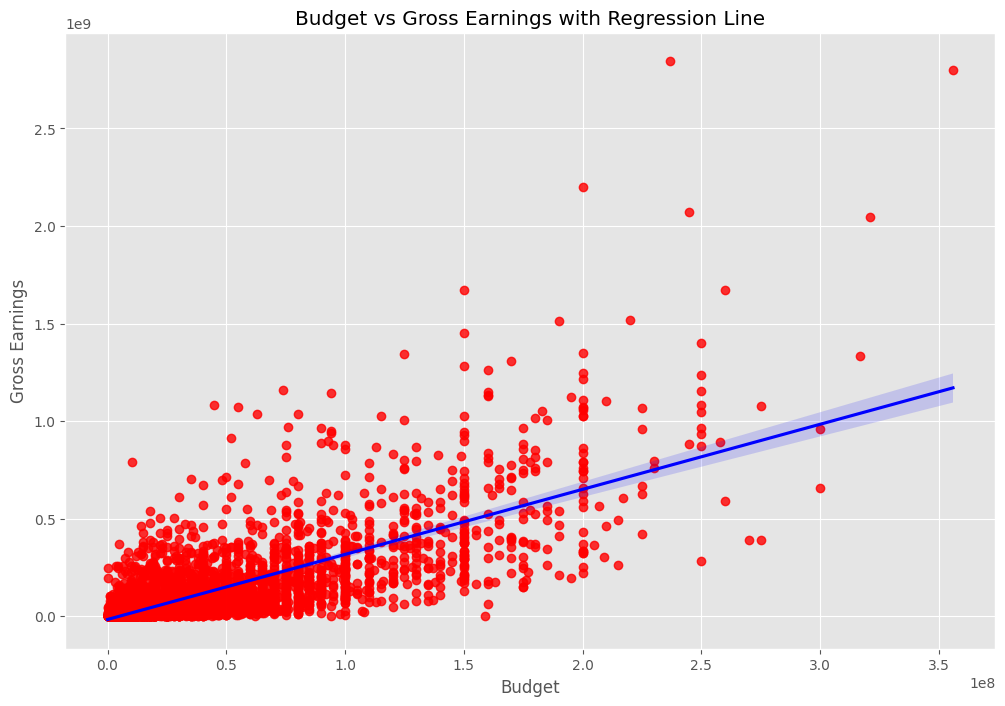

In [40]:
#Scatter plot budget vs gross 

sns.regplot(x='budget', y='gross', data=df, scatter_kws={"color": "red"}, line_kws={"color": "blue"})
plt.xlabel('Budget')
plt.ylabel('Gross Earnings')
plt.title('Budget vs Gross Earnings with Regression Line')
plt.show()

In [41]:
# Calculate IQR bounds to find outliers in 'gross'.
Q1 = df['gross'].quantile(0.25)
Q3 = df['gross'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [42]:
# Identify movies that are outliers in terms of gross.
outliers = df[(df['gross'] < lower_bound) | (df['gross'] > upper_bound)]


In [43]:
# Sort outliers by 'gross' ascending to find lowest grossing outliers.
lowest_outliers = outliers.sort_values(by='gross', ascending=True)
print("Lowest Grossing Outliers:")
print(lowest_outliers[['name', 'budget', 'gross', 'company', 'year']].head(10))

Lowest Grossing Outliers:
                                   name     budget      gross  \
4571  Bridget Jones: The Edge of Reason   40000000  265126918   
4305             Something's Gotta Give   80000000  265328738   
2276                  Indecent Proposal   38000000  266614059   
2054                     Batman Returns   80000000  266892996   
5473          The Princess and the Frog  105000000  267045765   
6521             Exodus: Gods and Kings  140000000  268175631   
6380                               Epic  100000000  268426634   
5056                  American Gangster  100000000  269755430   
5344                          10,000 BC  105000000  269784201   
5269                        Gran Torino   33000000  269958228   

                              company       year  
4571               Universal Pictures 2004-01-01  
4305                Columbia Pictures 2003-01-01  
2276               Paramount Pictures 1993-01-01  
2054                     Warner Bros. 1992-01-01  
547

In [44]:
# Sort outliers by 'gross' descending to find highest grossing outliers
highest_outliers = outliers.sort_values(by='gross', ascending=False)

print("\nHighest Grossing Outliers:")

print(highest_outliers[['name', 'budget', 'gross', 'company', 'year']].head(10))


Highest Grossing Outliers:
                                            name     budget       gross  \
5445                                      Avatar  237000000  2847246203   
7445                           Avengers: Endgame  356000000  2797501328   
3045                                     Titanic  200000000  2201647264   
6663  Star Wars: Episode VII - The Force Awakens  245000000  2069521700   
7244                      Avengers: Infinity War  321000000  2048359754   
7480                               The Lion King  260000000  1670727580   
6653                              Jurassic World  150000000  1670516444   
6043                                The Avengers  220000000  1518815515   
6646                                   Furious 7  190000000  1515341399   
7494                                   Frozen II  150000000  1450026933   

                            company       year  
5445          Twentieth Century Fox 2009-01-01  
7445                 Marvel Studios 2019-01-01  

**Observations**
- Highest grossing outliers include:

- Avatar: Budget:2.84B
- Avengers: Endgame: Budget: 2.79B
- These outliers were kept in the analysis to preserve the full data distribution and understand extreme performance cases.

# ✅ Data Analysis

# Correlation Analysis Approach

In [45]:
pearson_corr = df['budget'].corr(df['gross'], method='pearson')
print(f"Pearson correlation between budget and gross: {pearson_corr:.2f}")

Pearson correlation between budget and gross: 0.74


In [46]:
spearman_corr = df['budget'].corr(df['gross'], method='spearman')
print(f"Spearman correlation between budget and gross: {spearman_corr:.2f}")

Spearman correlation between budget and gross: 0.69


**Observations**
- To understand the relationship between 'budget' and 'gross', two correlation methods were used (Pearson and Spearman) to make the assessment more robust. 
- The result of both tests (Pearson: 0.74 and Spearman:0.69) indicated that the relationship between budget and gross revenue in movies is strong and positive. 

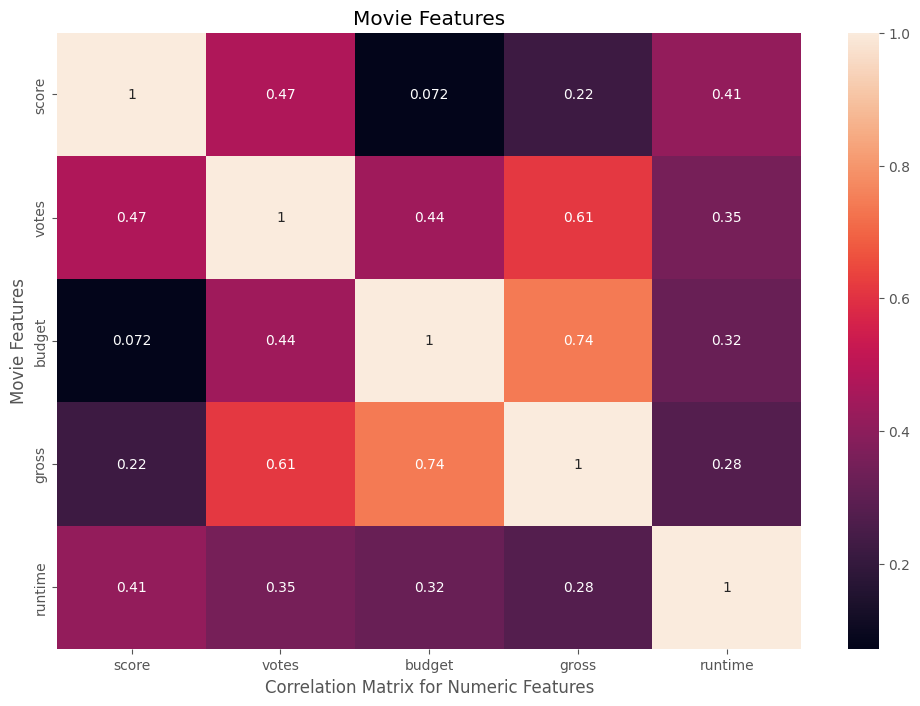

In [47]:
#Visualizing correlation in a  Matrix:

correlation_matrix = df.select_dtypes(include='number').corr(method='pearson') 
# we can checklist with Spearman also. 


sns.heatmap(correlation_matrix, annot=True)

plt.xlabel('Correlation Matrix for Numeric Features')
plt.ylabel('Movie Features')
plt.title('Movie Features')

plt.show()

In [48]:
# Select only numeric columns from the dataframe.
numeric_df = df.select_dtypes(include='number')

# Compute the correlation matrix for numeric features.
correlation_mat = numeric_df.corr()

# Unstack to get correlation pairs.
corr_pairs = correlation_mat.unstack()

# Sort the correlation pairs by value to see strongest correlations.
corr_pairs = corr_pairs.sort_values(key=lambda x: abs(x), ascending=False)

# Display all correlation pairs.
pd.set_option('display.max_rows', None)

# Print all correlation pairs
print(corr_pairs)

score    score      1.000000
votes    votes      1.000000
gross    gross      1.000000
budget   budget     1.000000
runtime  runtime    1.000000
gross    budget     0.740263
budget   gross      0.740263
votes    gross      0.614808
gross    votes      0.614808
votes    score      0.474349
score    votes      0.474349
votes    budget     0.439757
budget   votes      0.439757
runtime  score      0.414145
score    runtime    0.414145
votes    runtime    0.352331
runtime  votes      0.352331
         budget     0.318718
budget   runtime    0.318718
gross    runtime    0.275830
runtime  gross      0.275830
gross    score      0.222709
score    gross      0.222709
budget   score      0.072155
score    budget     0.072155
dtype: float64


# ✅ Conclusion

- Overall, a higher budget usually leads to higher earnings. However, some outliers like Avatar and Gran Torino show that certain films can outperform or deviate from this trend, highlighting that budget is an important but not the only factor affecting success.

# ✅ Data source: 
- Grijalva, D. (n.d.). Movies [Data set]. Kaggle. Retrieved April 13th, 2025, from: https://www.kaggle.com/datasets/danielgrijalvas/movies